# Dataloader + Training Loop
### NYU Depth V2 → MonocularSAMModel (DA V2 ViT-S + SAM-B Fusion)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os

In [2]:
import sys
sys.path.insert(0, '/kaggle/input/datasets/az0xutk/blocks/')  # folder where blocks.py lives

from blocks import (
    get_depth_encoder_features,
    DepthAnythingProjection,
    PositionalEmbeddings,
    TransformerBlock,
    DepthDecoder,
    DepthSAMFusion,
    get_point_prompt_from_mask,
    MonocularSAMModel
)

import inspect
print(inspect.getsource(get_point_prompt_from_mask))

def get_point_prompt_from_mask(gt_mask_np, mask_size=256, sam_size=1024):
    ys, xs = np.where(gt_mask_np > 0)
    if len(xs) == 0:
        cx, cy = sam_size // 2, sam_size // 2
    else:
        scale = sam_size / mask_size          # 1024/256 = 4.0
        cx = int(xs.mean() * scale)           # scale to SAM space
        cy = int(ys.mean() * scale)

    point_coords = torch.tensor([[[cx, cy]]], dtype=torch.float32)
    point_labels = torch.tensor([[1]], dtype=torch.int)
    return point_coords, point_labels



## initializing depth model

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

# ← Kaggle path first, before import
sys.path.insert(0, '/kaggle/input/datasets/az0xutk/depth-anything-model/Depth-Anything-V2/metric_depth')

from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

encoder   = 'vits'
max_depth = 10

check_path = f'/kaggle/input/datasets/az0xutk/depth-anything-v2/depth_anything_v2_metric_hypersim_{encoder}.pth'

model = DepthAnythingV2(**model_configs[encoder], max_depth=max_depth)
model.load_state_dict(torch.load(check_path, map_location='cpu'))
model = model.to(DEVICE).eval()
print(DEVICE)

xFormers not available
xFormers not available


cuda


## 1. Dataset

In [4]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class SceneNetDataset(Dataset):
    def __init__(self, base_path, train_folders, max_samples=50000):
        self.base_path   = base_path

        # ── Collect all frame paths ──────────────────────────
        self.samples = []
        for folder in train_folders:
            folder_path = f'{base_path}/{folder}/train'
            if not os.path.exists(folder_path):
                continue
            for traj in sorted(os.listdir(folder_path)):
                traj_path = f'{folder_path}/{traj}'
                for frame in sorted(os.listdir(traj_path)):
                    frame_path = f'{traj_path}/{frame}'
                    # get matching timestamps
                    photos = sorted(os.listdir(f'{frame_path}/photo'))
                    depths = set(os.listdir(f'{frame_path}/depth'))
                    instances = set(os.listdir(f'{frame_path}/instance'))
                    for p in photos:
                        ts = p.replace('.jpg', '.png')
                        if ts in depths and ts in instances:
                            self.samples.append({
                                'photo':    f'{frame_path}/photo/{p}',
                                'depth':    f'{frame_path}/depth/{ts}',
                                'instance': f'{frame_path}/instance/{ts}',
                            })

            if len(self.samples) >= max_samples:
                break

        # subsample if needed
        self.samples = self.samples[:max_samples]

        # ── Precompute fixed largest object per sample ───────
        print(f"Computing fixed classes for {len(self.samples)} samples...")
        self.fixed_classes = []
        for s in self.samples:
            inst = cv2.imread(s['instance'], cv2.IMREAD_UNCHANGED)
            u, c = np.unique(inst, return_counts=True)
            mask = u > 0  # remove background
            u, c = u[mask], c[mask]
            if len(u) == 0:
                self.fixed_classes.append(1)
            else:
                self.fixed_classes.append(u[np.argmax(c)])  # largest object

        print(f"Dataset ready: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
    
        # ── Load RGB ──────────────────────────────────────────
        img = cv2.imread(s['photo'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # (240, 320, 3)
    
        # ── Load depth (mm → meters, clip to 10m) ────────────
        depth = cv2.imread(s['depth'], cv2.IMREAD_UNCHANGED).astype(np.float32)
        depth = depth / 1000.0
        depth = np.clip(depth, 0, 10.0)
        gt_depth = torch.from_numpy(depth).unsqueeze(0)  # [1, 240, 320]
    
        # ── Load instance mask ────────────────────────────────
        inst = cv2.imread(s['instance'], cv2.IMREAD_UNCHANGED)
        chosen_class = self.fixed_classes[idx]
        binary_mask  = (inst == chosen_class).astype(np.float32)
        mask_256     = cv2.resize(binary_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        gt_mask = torch.from_numpy(mask_256).unsqueeze(0)  # [1, 256, 256]
    
        return {
            'gt_mask' : gt_mask,
            'gt_depth': gt_depth,
            'index'   : idx,
            'img'     : img
        }

In [5]:
BASE = '/kaggle/input/datasets/lovejeetmatharu/scenenet-rgb-d-part-1'

# use train_0 to train_3 for train, train_4 for val
train_dataset = SceneNetDataset(BASE, 
    train_folders=['train_0'],
    max_samples=5000)

val_dataset = SceneNetDataset(BASE,
    train_folders=['train_0'],
    max_samples=500)

Computing fixed classes for 5000 samples...
Dataset ready: 5000 samples
Computing fixed classes for 500 samples...
Dataset ready: 500 samples


## 2. Model Setup

In [6]:
from segment_anything import sam_model_registry

SAM_PATH = '/kaggle/input/datasets/az0xutk/sam-model/sam_vit_b_01ec64.pth'
sam_model = sam_model_registry['vit_b'](checkpoint=SAM_PATH)

depth_proj    = DepthAnythingProjection(in_channels=384, out_channels=256)
fusion_layer  = DepthSAMFusion()
depth_decoder = DepthDecoder(in_channels=256) 

fusion_model = MonocularSAMModel(
    sam_model            = sam_model,
    depth_anything_model = model,
    depth_proj           = depth_proj,
    fusion_layer         = fusion_layer,
    depth_decoder        = depth_decoder        # ← new
).to(DEVICE)

# Count trainable parameters
trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fusion_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 11,300,850 / 123,028,338


In [7]:
BATCH_SIZE = 4

def custom_collate(batch):
    return {
        'img'     : [b['img']      for b in batch],
        'gt_mask' : torch.stack([b['gt_mask']  for b in batch]),
        'gt_depth': torch.stack([b['gt_depth'] for b in batch]),
        'index'   : [b['index'] for b in batch]
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=custom_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=custom_collate)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 1250 | Val batches: 125


## 3. Loss Functions

In [9]:
def dice_loss(pred_logits, gt_mask, smooth=1.0):
    """
    Dice loss for segmentation.
    pred_logits: [B, 1, H, W] raw logits
    gt_mask:     [B, 1, H, W] binary float
    """
    pred  = torch.sigmoid(pred_logits)
    pred  = pred.view(pred.size(0), -1)
    gt    = gt_mask.view(gt_mask.size(0), -1)
    inter = (pred * gt).sum(dim=1)
    dice  = (2.0 * inter + smooth) / (pred.sum(dim=1) + gt.sum(dim=1) + smooth)
    return 1 - dice.mean()


def seg_loss(pred_logits, gt_mask):
    pos_weight = torch.tensor([5.0]).to(pred_logits.device)  # ← back but higher
    bce  = F.binary_cross_entropy_with_logits(pred_logits, gt_mask, pos_weight=pos_weight)
    dice = dice_loss(pred_logits, gt_mask)
    return bce + dice

def depth_loss(pred_depth, gt_depth):
    valid_mask = gt_depth > 0
    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=gt_depth.device)
    pred = torch.clamp(pred_depth[valid_mask], min=0.1)
    gt   = torch.clamp(gt_depth[valid_mask],   min=0.1)
    log_diff = torch.log(pred) - torch.log(gt)
    silog    = log_diff.pow(2).mean() - 0.5 * log_diff.mean().pow(2)
    return torch.clamp(silog, max=5.0)  # ← cap spikes

## 4. Training Loop

In [10]:
import os
print(os.listdir('/kaggle/input/datasets/az0xutk/13-epoch-model/'))


['best_model_13.pth', 'checkpoint_latest_1.pth']


In [ ]:
from IPython.display import FileLink
display(FileLink('checkpoints/checkpoint_latest.pth'))
display(FileLink('checkpoints/best_model.pth'))

In [10]:
import torch

ckpt_latest = torch.load('/kaggle/input/datasets/az0xutk/20-epoch-model/checkpoint_latest_20.pth', map_location='cpu')
ckpt_best   = torch.load('/kaggle/input/datasets/az0xutk/20-epoch-model/best_model_20.pth', map_location='cpu')

print(f"checkpoint_latest → epoch: {ckpt_latest['epoch']}")
print(f"best_model        → epoch: {ckpt_best['epoch']} | IoU: {ckpt_best['val_iou']:.4f}")
print(f"history epochs so far: {len(ckpt_latest['history']['val_iou'])}")
print(f"val IoU history: {[round(x,4) for x in ckpt_latest['history']['val_iou']]}")

checkpoint_latest → epoch: 20
best_model        → epoch: 19 | IoU: 0.9226
history epochs so far: 20
val IoU history: [0.7286, 0.7766, 0.811, 0.8582, 0.8541, 0.859, 0.8855, 0.8939, 0.8959, 0.9072, 0.9072, 0.9075, 0.9138, 0.9155, 0.9154, 0.9185, 0.9191, 0.9166, 0.9226, 0.9192]


In [ ]:
def get_depth_features_batched(fusion_model, raw_imgs_np):
    """
    Run DA V2 encoder on a batch of numpy images.
    Returns: [B, 384, pH, pW] depth features on DEVICE
    """
    all_features = []

    for raw_img in raw_imgs_np:
        features   = {}
        input_size = {}

        def hook(module, input, output):
            features['out'] = output

        handle = fusion_model.depth_model.pretrained.blocks[-1].register_forward_hook(hook)

        with torch.no_grad():
            image, (h, w) = fusion_model.depth_model.image2tensor(raw_img, input_size=518)
            pH = image.shape[2] // 14
            pW = image.shape[3] // 14
            fusion_model.depth_model.forward(image.to(DEVICE))

        handle.remove()

        enc     = features['out'][:, 1:, :]                           # remove CLS
        B, N, C = enc.shape
        spatial = enc.reshape(B, pH, pW, C).permute(0, 3, 1, 2)      # [1, 384, pH, pW]

        # Resize to fixed size for batching
        spatial = F.interpolate(spatial, size=(37, 37), mode='bilinear', align_corners=False)
        all_features.append(spatial)

    return torch.cat(all_features, dim=0)   # [B, 384, 37, 37]


# ── Redefine train/val functions (fast version) ───────────────────────────────
def train_one_epoch(fusion_model, loader, optimizer, device, epoch):
    fusion_model.train()
    fusion_model.sam.image_encoder.eval()
    fusion_model.depth_model.eval()
    total_loss = total_seg = total_dep = 0.0
    loop = tqdm(loader, leave=True)
    max_grad = 0.0

    for batch in loop:
        imgs     = batch['img']
        gt_mask  = batch['gt_mask'].to(device)
        gt_depth = batch['gt_depth'].to(device)
        optimizer.zero_grad()

        sam_feats, depth_feats = [], []
        with torch.no_grad():
            for img in imgs:
                img_bgr  = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
                img_1024 = cv2.resize(img, (1024, 1024))
                sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
                sam_inp  = sam_inp.unsqueeze(0).to(device)
                sam_feats.append(fusion_model.sam.image_encoder(sam_inp).squeeze(0))
                depth_feats.append(
                    get_depth_encoder_features(fusion_model.depth_model, img_bgr).squeeze(0)
                )

        sam_feat   = torch.stack(sam_feats).to(device)
        depth_feat = torch.stack(depth_feats).to(device)

        # ── first pass: no prompt, get depth ──────────────────
        with torch.no_grad():
            _, _, pred_depth_prompt = fusion_model(sam_feat, depth_feat)
            depth_small = F.interpolate(pred_depth_prompt, size=(256, 256), mode='bilinear', align_corners=False)
            point_coords_list, point_labels_list = [], []
            for b in range(gt_mask.shape[0]):
                depth_b      = depth_small[b, 0].cpu().numpy()
                mask_b       = gt_mask[b, 0].cpu().numpy()
                masked_depth = depth_b * mask_b + 1e6 * (1 - mask_b)
                y, x         = np.unravel_index(masked_depth.argmin(), masked_depth.shape)
                point_coords_list.append([[x, y]])
                point_labels_list.append([1])
            point_coords = torch.tensor(point_coords_list, dtype=torch.float32).to(device)
            point_labels = torch.tensor(point_labels_list, dtype=torch.int).to(device)

        # ── second pass: with prompt, gets gradients ──────────
        low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat, point_coords, point_labels)

        loss_seg           = seg_loss(low_res_masks, gt_mask)
        pred_depth_resized = F.interpolate(pred_depth, size=(240, 320), mode='bilinear', align_corners=False)
        loss_depth         = depth_loss(pred_depth_resized, gt_depth)
        depth_weight       = min(0.001 * (epoch + 1), 0.1)
        loss               = loss_seg + depth_weight * loss_depth

        loss.backward()
        total_norm = torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), max_norm=1.0)
        optimizer.step()

        max_grad    = max(max_grad, total_norm.item())
        total_loss += loss.item()
        total_seg  += loss_seg.item()
        total_dep  += loss_depth.item()
        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            seg=f"{loss_seg.item():.4f}",
            depth=f"{loss_depth.item():.4f}",
            grad=f"{total_norm:.2f}"
        )

    n = len(loader)
    print(f"  Max grad this epoch: {max_grad:.2f}")
    return total_loss/n, total_seg/n, total_dep/n


@torch.no_grad()
def validate(fusion_model, loader, device):
    fusion_model.eval()
    total_loss = total_iou = 0.0

    for batch in tqdm(loader, leave=False, desc='Validating'):
        imgs     = batch['img']
        gt_mask  = batch['gt_mask'].to(device)
        gt_depth = batch['gt_depth'].to(device)

        sam_feats, depth_feats = [], []
        for img in imgs:
            img_bgr  = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img_1024 = cv2.resize(img, (1024, 1024))
            sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
            sam_inp  = sam_inp.unsqueeze(0).to(device)
            sam_feats.append(fusion_model.sam.image_encoder(sam_inp).squeeze(0))
            depth_feats.append(
                get_depth_encoder_features(fusion_model.depth_model, img_bgr).squeeze(0)
            )

        sam_feat   = torch.stack(sam_feats).to(device)
        depth_feat = torch.stack(depth_feats).to(device)

        low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat)

        pred_depth_resized = F.interpolate(pred_depth, size=(240, 320), mode='bilinear', align_corners=False)
        total_loss += (seg_loss(low_res_masks, gt_mask) +
                       0.001 * depth_loss(pred_depth_resized, gt_depth)).item()

        pred_binary = (torch.sigmoid(low_res_masks) > 0.3).float()
        inter = (pred_binary * gt_mask).sum(dim=(1,2,3))
        union = (pred_binary + gt_mask).clamp(0,1).sum(dim=(1,2,3))
        total_iou += (inter / (union + 1e-6)).mean().item()

    n = len(loader)
    return total_loss/n, total_iou/n


# ── optimizer / scheduler ──────────────────────────────────────────────────
trainable_params = [
    {'params': fusion_model.depth_proj.parameters(),      'lr': 1e-4},
    {'params': fusion_model.fusion_layer.parameters(),    'lr': 1e-4},
    {'params': fusion_model.depth_decoder.parameters(),   'lr': 1e-4},
    {'params': fusion_model.sam.mask_decoder.parameters(),'lr': 1e-5},
]
optimizer  = optim.AdamW(trainable_params, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
NUM_EPOCHS = 20
SAVE_DIR   = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Resume from checkpoint ─────────────────────────────────────────────────
start_epoch  = 0
best_val_iou = 0.0
history      = {'train_loss': [], 'train_seg': [], 'train_depth': [], 'val_loss': [], 'val_iou': []}

RESUME_PATH = '/kaggle/input/datasets/az0xutk/13-epoch-model/checkpoint_latest_1.pth'
if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=DEVICE)
    fusion_model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch  = ckpt['epoch']
    history      = ckpt.get('history', history)
    best_val_iou = max(history['val_iou']) if history['val_iou'] else 0.0
    print(f"Resumed from epoch {start_epoch}, best IoU so far: {best_val_iou:.4f}")
else:
    print("Starting from scratch")

# ── Training loop ──────────────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"{'='*60}")

    train_loss, train_seg, train_depth = train_one_epoch(fusion_model, train_loader, optimizer, DEVICE, epoch)
    val_loss, val_iou                  = validate(fusion_model, val_loader, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_seg'].append(train_seg)
    history['train_depth'].append(train_depth)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)

    print(f"Train → loss: {train_loss:.4f} | seg: {train_seg:.4f} | depth: {train_depth:.4f}")
    print(f"Val   → loss: {val_loss:.4f}   | IoU: {val_iou:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            'epoch': epoch+1, 'model_state_dict': fusion_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_iou': val_iou, 'val_loss': val_loss, 'history': history,
        }, os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  ✓ Saved best model (IoU: {best_val_iou:.4f})")

    # always overwrite latest so resume is easy
    torch.save({
        'epoch': epoch+1, 'model_state_dict': fusion_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'history': history,
    }, os.path.join(SAVE_DIR, 'checkpoint_latest.pth'))
    print(f"  ✓ Saved checkpoint epoch {epoch+1}")

print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")

## 5. Plot Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_seg'],   label='Seg Loss')
axes[1].plot(history['train_depth'], label='Depth Loss')
axes[1].set_title('Train Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_iou'], label='Val IoU', color='green')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 6. Load Best Model & Inference

In [ ]:
SAVE_DIR = '/kaggle/input/datasets/az0xutk/model-parameters-13-epoch/best_model.pth'

fusion_model.eval()
sample_no = 15
sample    = val_dataset[sample_no]
img_np    = sample['img']           # (240, 320, 3) RGB
gt_mask   = sample['gt_mask']       # [1, 256, 256]

# compute features on the fly
img_bgr  = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
img_1024 = cv2.resize(img_np, (1024, 1024))
sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
sam_inp  = sam_inp.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    sam_feat   = fusion_model.sam.image_encoder(sam_inp)
    depth_feat = get_depth_encoder_features(fusion_model.depth_model, img_bgr).to(DEVICE)

    _, _, pred_depth = fusion_model(sam_feat, depth_feat)

    depth_small    = F.interpolate(pred_depth, size=(256,256), mode='bilinear', align_corners=False)
    depth_np_small = depth_small.squeeze().cpu().numpy()
    y, x = np.unravel_index(depth_np_small.argmin(), depth_np_small.shape)
    point_coords = torch.tensor([[[x, y]]], dtype=torch.float32).to(DEVICE)
    point_labels = torch.tensor([[1]], dtype=torch.int).to(DEVICE)

    low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat, point_coords, point_labels)

# rest of visualization unchanged...
pred_mask  = (torch.sigmoid(low_res_masks) > 0.3).float().squeeze().cpu().numpy()
depth_np   = pred_depth.squeeze().cpu().numpy()

mask_full    = F.interpolate(
    (torch.sigmoid(low_res_masks) > 0.3).float(),
    size=(240, 320), mode='nearest'
).squeeze().cpu().numpy()
object_depth = depth_np * mask_full

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(img_np)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(gt_mask.squeeze().numpy(), cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

pred_mask = (torch.sigmoid(low_res_masks) > 0.3).float().squeeze().cpu().numpy()
axes[2].imshow(pred_mask, cmap='gray')
axes[2].set_title(f'Predicted Mask (SAM conf: {iou_pred.item():.3f})')
axes[2].axis('off')

axes[3].imshow(depth_np, cmap='plasma')
axes[3].set_title('Predicted Depth (meters)')
axes[3].axis('off')
plt.colorbar(axes[3].images[0], ax=axes[3])

axes[4].imshow(object_depth, cmap='plasma')
axes[4].set_title('Object Depth Only')
axes[4].axis('off')
plt.colorbar(axes[4].images[0], ax=axes[4])

plt.tight_layout()
plt.show()
fusion_model.train()
fusion_model.sam.image_encoder.eval()
fusion_model.depth_model.eval()

Loaded checkpoint from epoch 19 | IoU: 0.9226
GT depth range: 1.71 - 10.00
GT mask coverage: 0.428


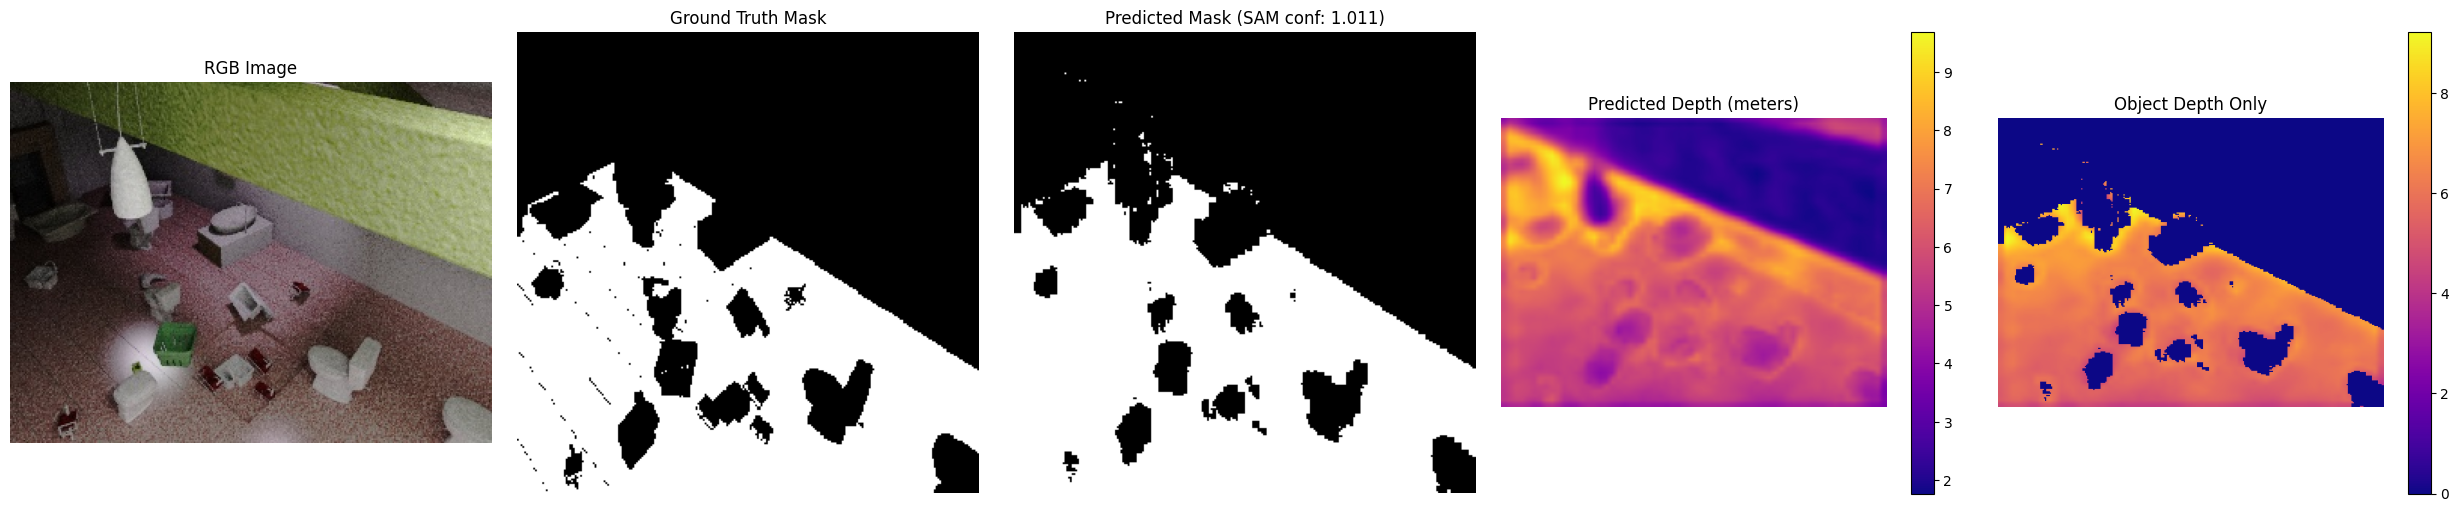

In [11]:
SAVE_DIR = '/kaggle/input/datasets/az0xutk/20-epoch-model/'
ckpt = torch.load(os.path.join(SAVE_DIR, 'best_model_20.pth'), map_location=DEVICE)
fusion_model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} | IoU: {ckpt['val_iou']:.4f}")

fusion_model.eval()
sample_no = 150 # change this to try different samples

# load from SceneNet val dataset
sample = val_dataset[sample_no]
print(f"GT depth range: {sample['gt_depth'].min():.2f} - {sample['gt_depth'].max():.2f}")
print(f"GT mask coverage: {sample['gt_mask'].mean():.3f}")
img_np  = sample['img']        # (240, 320, 3) RGB
gt_mask = sample['gt_mask']    # [1, 256, 256]

# compute features on the fly
img_bgr  = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
img_1024 = cv2.resize(img_np, (1024, 1024))
sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
sam_inp  = sam_inp.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    sam_feat   = fusion_model.sam.image_encoder(sam_inp)
    depth_feat = get_depth_encoder_features(fusion_model.depth_model, img_bgr).to(DEVICE)

    _, _, pred_depth = fusion_model(sam_feat, depth_feat)

    depth_small    = F.interpolate(pred_depth, size=(256, 256), mode='bilinear', align_corners=False)
    depth_np_small = depth_small.squeeze().cpu().numpy()
    y, x = np.unravel_index(depth_np_small.argmin(), depth_np_small.shape)
    point_coords = torch.tensor([[[x, y]]], dtype=torch.float32).to(DEVICE)
    point_labels = torch.tensor([[1]], dtype=torch.int).to(DEVICE)

    low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat, point_coords, point_labels)

pred_mask    = (torch.sigmoid(low_res_masks) > 0.3).float().squeeze().cpu().numpy()
depth_vis    = F.interpolate(pred_depth, size=(240, 320), mode='bilinear', align_corners=False)
depth_np_full = depth_vis.squeeze().cpu().numpy()
mask_full    = F.interpolate(
    (torch.sigmoid(low_res_masks) > 0.3).float(),
    size=(240, 320), mode='nearest'
).squeeze().cpu().numpy()
object_depth = depth_np_full * mask_full

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(img_np);                        axes[0].set_title('RGB Image');           axes[0].axis('off')
axes[1].imshow(gt_mask.squeeze().numpy(), cmap='gray'); axes[1].set_title('Ground Truth Mask');   axes[1].axis('off')
axes[2].imshow(pred_mask, cmap='gray');        axes[2].set_title(f'Predicted Mask (SAM conf: {iou_pred.item():.3f})'); axes[2].axis('off')
axes[3].imshow(depth_np_full, cmap='plasma');  axes[3].set_title('Predicted Depth (meters)'); axes[3].axis('off')
plt.colorbar(axes[3].images[0], ax=axes[3])
axes[4].imshow(object_depth, cmap='plasma');   axes[4].set_title('Object Depth Only');   axes[4].axis('off')
plt.colorbar(axes[4].images[0], ax=axes[4])
plt.tight_layout()
plt.show()

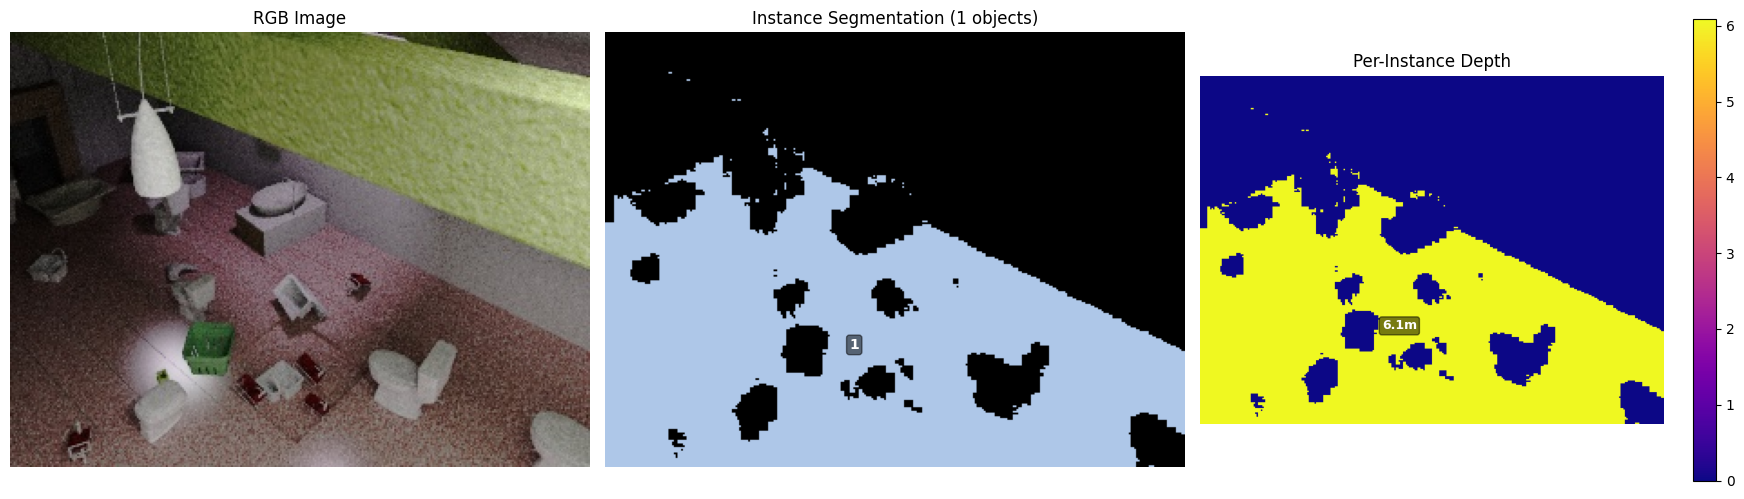

Instance depths (meters):
  Instance 1: 6.09m


In [12]:
def get_instance_segmentation(fusion_model, img_np, device, max_objects=10, iou_threshold=0.3):
    fusion_model.eval()
    
    img_bgr  = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    img_1024 = cv2.resize(img_np, (1024, 1024))
    sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
    sam_inp  = sam_inp.unsqueeze(0).to(device)

    with torch.no_grad():
        sam_feat   = fusion_model.sam.image_encoder(sam_inp)
        depth_feat = get_depth_encoder_features(fusion_model.depth_model, img_bgr).to(device)
        _, _, pred_depth = fusion_model(sam_feat, depth_feat)

    # build instance map by sampling points across image
    H, W = img_np.shape[:2]
    instance_map  = np.zeros((H, W), dtype=np.int32)
    instance_depths = {}
    instance_id   = 1

    # sample a grid of prompt points
    ys = np.linspace(20, H-20, 8).astype(int)
    xs = np.linspace(20, W-20, 10).astype(int)

    visited = np.zeros((H, W), dtype=bool)

    for y in ys:
        for x in xs:
            # skip if already assigned
            if visited[y, x]:
                continue

            point_coords = torch.tensor([[[x, y]]], dtype=torch.float32).to(device)
            point_labels = torch.tensor([[1]], dtype=torch.int).to(device)

            with torch.no_grad():
                low_res_masks, iou_pred, pred_depth = fusion_model(
                    sam_feat, depth_feat, point_coords, point_labels
                )

            # skip low confidence predictions
            if iou_pred.item() < iou_threshold:
                continue

            mask = F.interpolate(
                (torch.sigmoid(low_res_masks) > 0.3).float(),
                size=(H, W), mode='nearest'
            ).squeeze().cpu().numpy().astype(bool)

            mask_coverage = mask.sum() / (H * W)
            if mask_coverage < 0.005 or mask_coverage > 0.6:
                continue

            # skip if mostly already assigned
            overlap = (visited & mask).sum() / (mask.sum() + 1e-6)
            if overlap > 0.3:
                continue

            # assign instance
            instance_map[mask & ~visited] = instance_id
            visited |= mask

            # get mean depth for this instance
            depth_full = F.interpolate(pred_depth, size=(H, W), mode='bilinear', align_corners=False)
            depth_np   = depth_full.squeeze().cpu().numpy()
            instance_depths[instance_id] = float(depth_np[mask].mean())

            instance_id += 1

    return instance_map, instance_depths


# ── visualize ──────────────────────────────────────────────────────────────
instance_map, instance_depths = get_instance_segmentation(fusion_model, img_np, DEVICE,iou_threshold=0.1)

# color each instance differently
colored = np.zeros((*instance_map.shape, 3), dtype=np.uint8)
colors = plt.cm.tab20(np.linspace(0, 1, max(instance_map.max() + 1, 20)))
for iid in range(1, instance_map.max() + 1):
    colored[instance_map == iid] = (np.array(colors[iid % 20][:3]) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_np)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(colored)
axes[1].set_title(f'Instance Segmentation ({instance_map.max()} objects)')
axes[1].axis('off')
# ── add instance labels ──
for iid in range(1, instance_map.max() + 1):
    ys_iid, xs_iid = np.where(instance_map == iid)
    if len(ys_iid) == 0:
        continue
    cy, cx = int(ys_iid.mean()), int(xs_iid.mean())
    axes[1].text(cx, cy, str(iid), color='white', fontsize=10,
                 fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

# depth per instance
depth_colored = np.zeros(instance_map.shape)
for iid, d in instance_depths.items():
    depth_colored[instance_map == iid] = d
axes[2].imshow(depth_colored, cmap='plasma')
axes[2].set_title('Per-Instance Depth')
axes[2].axis('off')
# ── add depth labels ──
for iid, d in instance_depths.items():
    ys_iid, xs_iid = np.where(instance_map == iid)
    if len(ys_iid) == 0:
        continue
    cy, cx = int(ys_iid.mean()), int(xs_iid.mean())
    axes[2].text(cx, cy, f'{d:.1f}m', color='white', fontsize=9,
                 fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
plt.colorbar(axes[2].images[0], ax=axes[2])

plt.tight_layout()
plt.show()

print("Instance depths (meters):")
for iid, d in instance_depths.items():
    print(f"  Instance {iid}: {d:.2f}m")

In [ ]:
for sample_no in range(500):
    sample = val_dataset[sample_no]
    img_np = sample['img']
    instance_map, instance_depths = get_instance_segmentation(
        fusion_model, img_np, DEVICE, iou_threshold=0.1)
    print(f"sample {sample_no}: {instance_map.max()} instances")